# Damping Values Used in Simulations

Three subplots (Heave, Pitch, Roll). Each simulation category is a single point:
- **x-axis**: linear damping
- **y-axis**: quadratic damping

Colors: Low = blue, Linhigh = orange, Quadhigh = green, Average = red.

On top of each point, the **linear radiation damping range** is added to the linear value and shown as a horizontal error bar (lighter shade of the same color), extending the point to the right from `linear + range_min` to `linear + range_max`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [2]:
# --- Data from Table 4.4 ---
categories = ["Low", "Linhigh", "Quadhigh", "Average"]
colors = {
    "Low": "tab:blue",
    "Linhigh": "tab:orange",
    "Quadhigh": "tab:green",
    "Average": "tab:red",
}

# linear damping (x), quadratic damping (y) per DOF
data = {
    "Heave": {
        "linear":    {"Low": 1.0, "Linhigh": 6.5, "Quadhigh": 1.0, "Average": 3.3},
        "quadratic": {"Low": 1.0, "Linhigh": 1.0, "Quadhigh": 4.0, "Average": 2.4},
        "radiation_range": (0.47, 1.24),
        "xlabel": "Linear Damping [kN/(m/s)]",
        "ylabel": "Quadratic Damping [kN/(m/s)$^2$]",
    },
    "Pitch": {
        "linear":    {"Low": 150.0, "Linhigh": 325.0, "Quadhigh": 150.0, "Average": 248.0},
        "quadratic": {"Low": 200.0, "Linhigh": 200.0, "Quadhigh": 1300.0, "Average": 640.0},
        "radiation_range": (1.0, 134.0),
        "xlabel": "Linear Damping [kNm/(rad/s)]",
        "ylabel": "Quadratic Damping [kNm/(rad/s)$^2$]",
    },
    "Roll": {
        "linear":    {"Low": 100.0, "Linhigh": 300.0, "Quadhigh": 100.0, "Average": 233.0},
        "quadratic": {"Low": 300.0, "Linhigh": 300.0, "Quadhigh": 1300.0, "Average": 305.0},
        "radiation_range": (1.0, 135.0),
        "xlabel": "Linear Damping [kNm/(rad/s)]",
        "ylabel": "Quadratic Damping [kNm/(rad/s)$^2$]",
    },
}

dofs = ["Heave", "Pitch", "Roll"]

In [3]:
def lighten(color, amount=0.55):
    """Return a lighter shade of `color` by blending it toward white.
    amount=0 -> original color, amount=1 -> white."""
    r, g, b = mcolors.to_rgb(color)
    return (r + (1 - r) * amount,
            g + (1 - g) * amount,
            b + (1 - b) * amount)

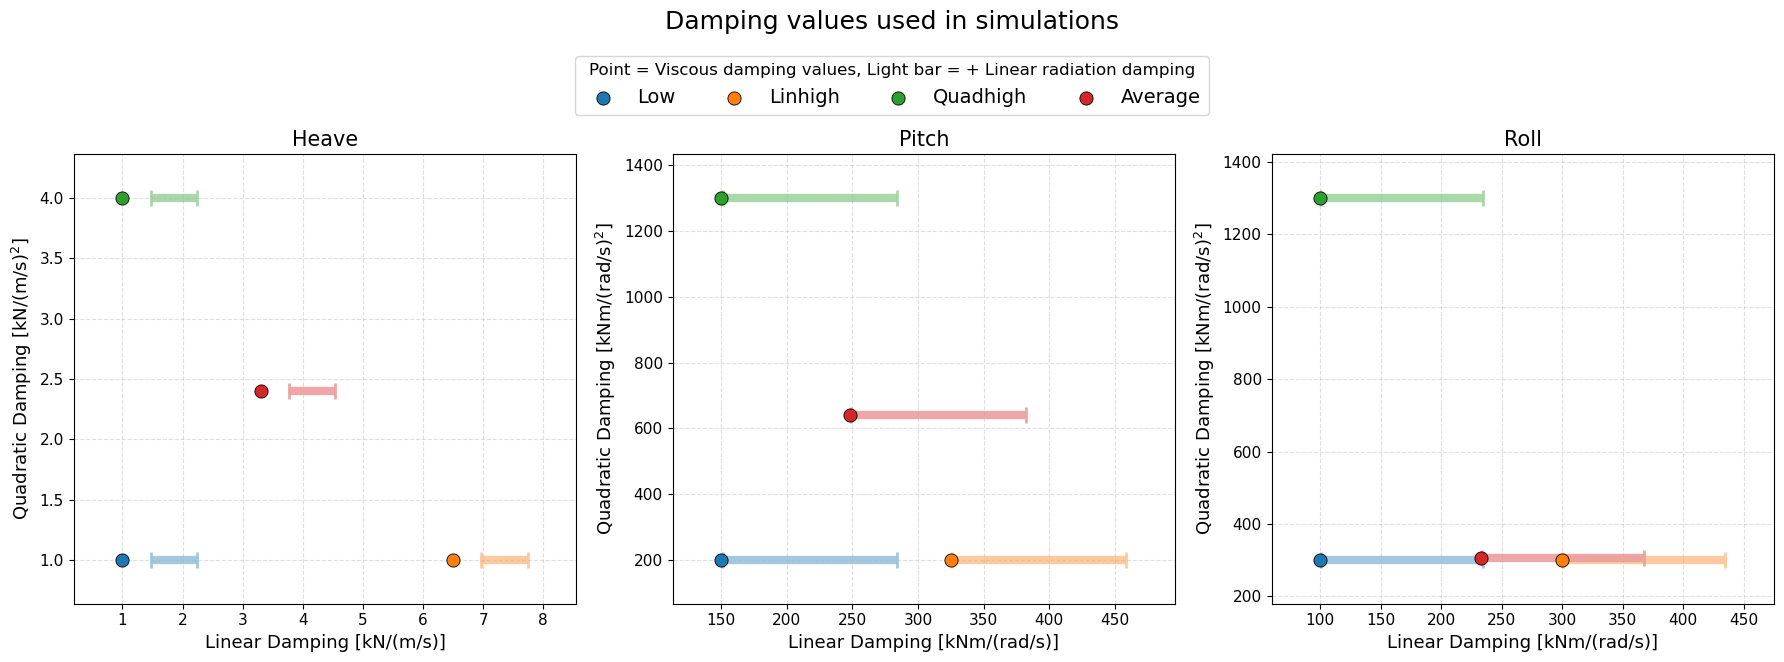

In [10]:
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, dof in zip(axes, dofs):
    d = data[dof]
    rmin, rmax = d["radiation_range"]

    for cat in categories:
        x = d["linear"][cat]
        y = d["quadratic"][cat]
        c = colors[cat]
        c_light = lighten(c, 0.55)

        # Linear value + radiation damping range, drawn as a horizontal error bar
        # extending to the right (lighter shade of the category color).
        x_lo = x + rmin
        x_hi = x + rmax
        x_center = 0.5 * (x_lo + x_hi)
        ax.errorbar(
            x_center, y,
            xerr=[[x_center - x_lo], [x_hi - x_center]],
            fmt="none", ecolor=c_light, elinewidth=6, capsize=6,
            capthick=2, alpha=0.9, zorder=1,
        )

        # Original data point (full color) on top
        ax.scatter(x, y, color=c, s=90, zorder=3, label=cat,
                   edgecolors="black", linewidths=0.6)

    ax.set_title(dof)
    ax.set_xlabel(d["xlabel"])
    ax.set_ylabel(d["ylabel"])
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.margins(0.12)

# Single shared legend (categories + range explanation)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, fontsize=14,
           bbox_to_anchor=(0.5, 1.04), frameon=True,
           title="Point = Viscous damping values, Light bar = + Linear radiation damping")

fig.suptitle("Damping values used in simulations", fontsize=18, y=1.10)
fig.tight_layout()
plt.savefig("damping_values.png", dpi=200, bbox_inches="tight")
plt.show()